In [108]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [109]:
url_train = "/content/sample_data/train.csv"
url_test = "/content/sample_data/test_features.csv"
df_train = pd.read_csv(url_train)
df_test = pd.read_csv(url_test)

df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   patient_id                     800 non-null    int64  
 1   Возраст                        800 non-null    int64  
 2   Пол_мужской                    800 non-null    int64  
 3   ИМТ                            800 non-null    float64
 4   Окружность_талии_см            800 non-null    float64
 5   САД_мм_рт_ст                   800 non-null    float64
 6   ДАД_мм_рт_ст                   800 non-null    float64
 7   Пульсовое_давление             800 non-null    float64
 8   Глюкоза_натощак_ммоль_л        800 non-null    float64
 9   HbA1c_%                        800 non-null    float64
 10  ЛПНП_ммоль_л                   765 non-null    float64
 11  ЛПВП_ммоль_л                   755 non-null    float64
 12  Триглицериды_ммоль_л           754 non-null    flo

In [110]:
df_test = df_test.drop(['ЛПНП_ммоль_л', 'ЛПВП_ммоль_л', 'Триглицериды_ммоль_л', 'СКФ_мл_мин'], axis = 1) # удаляем целевую переменную и столбцы с пропущенными значениямм
X = df_train.drop(['prediction', 'ЛПНП_ммоль_л', 'ЛПВП_ммоль_л', 'Триглицериды_ммоль_л', 'СКФ_мл_мин'], axis = 1).values.astype(np.float32)
y = df_train['prediction'].values.astype(np.float32).reshape(-1, 1)

print(f"Размер выборки: {X.shape[0]}, число признаков: {X.shape[1]}")

Размер выборки: 800, число признаков: 14


In [111]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [112]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [113]:
X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train)
X_test_t = torch.tensor(X_test)
y_test_t = torch.tensor(y_test)

In [114]:
batch_size = 32
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [115]:
class FeaturesFFN(nn.Module):
  def __init__(self, input_dim):
    super().__init__()
    self.fc1 = nn.Linear(input_dim, 64)
    self.fc2 = nn.Linear(64, 32)
    self.fc3 = nn.Linear(32, 1)
    self.relu = nn.ReLU()
    self.dropout = nn.Dropout(0.2)

  def forward(self, x):
    x = self.relu(self.fc1(x))
    x = self.dropout(x)
    x = self.relu(self.fc2(x))
    x = self.fc3(x)
    return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FeaturesFFN(X_train.shape[1]).to(device)

In [116]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [117]:
epochs = 100
train_losses, test_losses = [], []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)
    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    epoch_test_loss = val_loss / len(test_loader.dataset)
    test_losses.append(epoch_test_loss)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs} — Train Loss: {epoch_train_loss:.4f}, Test Loss: {epoch_test_loss:.4f}")

Epoch 20/100 — Train Loss: 0.1172, Test Loss: 0.1737
Epoch 40/100 — Train Loss: 0.0779, Test Loss: 0.1971
Epoch 60/100 — Train Loss: 0.0510, Test Loss: 0.2383
Epoch 80/100 — Train Loss: 0.0345, Test Loss: 0.2748
Epoch 100/100 — Train Loss: 0.0391, Test Loss: 0.3045


In [118]:
model.eval()
y_pred_prob = []
y_true = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        probs = torch.sigmoid(outputs)
        y_pred_prob.extend(probs.cpu().numpy().flatten())
        y_true.extend(y_batch.numpy().flatten())

y_pred_prob = np.array(y_pred_prob)
y_true = np.array(y_true)
y_pred_class = (y_pred_prob >= 0.5).astype(int)

In [119]:
print("\n" + "="*50)
print("Оценка на тестовой выборке:")
print("="*50)
print(f"Accuracy:  {accuracy_score(y_true, y_pred_class):.4f}")
print(f"Precision: {precision_score(y_true, y_pred_class):.4f}")
print(f"Recall:    {recall_score(y_true, y_pred_class):.4f}")
print(f"F1-score:  {f1_score(y_true, y_pred_class):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_true, y_pred_prob):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred_class))


Оценка на тестовой выборке:
Accuracy:  0.9000
Precision: 0.7826
Recall:    0.6207
F1-score:  0.6923
ROC-AUC:   0.9587

Confusion Matrix:
[[126   5]
 [ 11  18]]


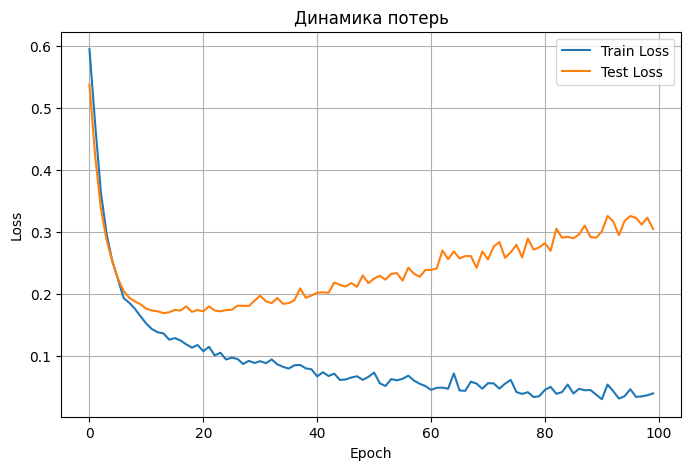

In [120]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Динамика потерь')
plt.legend()
plt.grid(True)
plt.show()

In [121]:
test_scaler = StandardScaler()
test = test_scaler.fit_transform(df_test.values.astype(np.float32))
test_t = torch.tensor(test)

In [122]:
test_pred_prob = []

with torch.no_grad():
  test_t = test_t.to(device)
  test_outputs = model(test_t)
  test_probs = torch.sigmoid(test_outputs)
  test_pred_prob.extend(test_probs.cpu().numpy().flatten())

test_pred_prob = np.array(test_pred_prob)
test_pred_class = (test_pred_prob >= 0.5).astype(int)
test_pred_class

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0])

In [123]:
df_pred = pd.DataFrame({
    'patient_id': df_test['patient_id'].values,
    'prediction': test_pred_class
})
df_pred.to_csv('task1_predictions.csv')